In [1]:
import os
import joblib


import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import plotly.graph_objects as go
from scipy.stats import gaussian_kde
import plotly.express as px
import seaborn as sns
import glob


from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import f1_score, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

In [2]:
data_directory = 'G:/My Drive/kaggle_data/FoG_prediction/'

In [3]:
def fill_missing_values(df):
    """
    Replaces missing values with the median value for each numerical column.

    :param df: pandas DataFrame, the dataset in which missing values need to be replaced
    :return: pandas DataFrame, the dataset with replaced missing values
    """
    numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns  # Selecting all numerical columns
    for col in numeric_cols:
        median = df[col].median()  # Finding the Median Value of a Column
        df[col].fillna(median, inplace=True)   # Replacing Missing Values with the Median Value
    return df

In [4]:
def explore_dataframe(df):
    print("Shape of dataframe:", df.shape)
    
    display(df.head())
    
    print("Info of dataframe:\n")
    df.info()
         
    print("Missing values in dataframe:\n", df.isnull().sum())
    
    print("Duplicate rows in dataframe:", df.duplicated().sum())

In [5]:
def check_missing_values(df):
    """
    Checks the count of missing values in each column of a DataFrame.

    :param df: pandas.DataFrame, the DataFrame to check for missing values.
    :return: pandas.DataFrame, the DataFrame with information about missing values.
    """
    return df.isnull().sum()

### Metadata

In [6]:
tdcsfog_metadata_df = pd.read_csv(data_directory+"tdcsfog_metadata.csv")
defog_metadata_df = pd.read_csv(data_directory+"defog_metadata.csv")
subjects_df = pd.read_csv(data_directory+"subjects.csv")
events_df = pd.read_csv(data_directory+"events.csv")
tasks_df = pd.read_csv(data_directory+"tasks.csv")
daily_metadata_df = pd.read_csv(data_directory+"daily_metadata.csv")

In [7]:
explore_dataframe(tdcsfog_metadata_df)

Shape of dataframe: (833, 5)


,Id,Subject,Visit,Test,Medication
0,003f117e14,4dc2f8,3,2,on
1,009ee11563,f62eec,4,2,on
2,011322847a,231c3b,2,2,on
3,01d0fe7266,231c3b,2,1,off
4,024418ba39,fa8764,19,3,on


Info of dataframe:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 833 entries, 0 to 832
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Id          833 non-null    object
 1   Subject     833 non-null    object
 2   Visit       833 non-null    int64 
 3   Test        833 non-null    int64 
 4   Medication  833 non-null    object
dtypes: int64(2), object(3)
memory usage: 32.7+ KB
Missing values in dataframe:
 Id            0
Subject       0
Visit         0
Test          0
Medication    0
dtype: int64
Duplicate rows in dataframe: 0


In [8]:
explore_dataframe(defog_metadata_df)

Shape of dataframe: (137, 4)


,Id,Subject,Visit,Medication
0,02ab235146,e1f62e,2,on
1,02ea782681,ae2d35,2,on
2,06414383cf,8c1f5e,2,off
3,092b4c1819,2874c5,1,off
4,0a900ed8a2,0e3d49,2,on


Info of dataframe:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 137 entries, 0 to 136
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Id          137 non-null    object
 1   Subject     137 non-null    object
 2   Visit       137 non-null    int64 
 3   Medication  137 non-null    object
dtypes: int64(1), object(3)
memory usage: 4.4+ KB
Missing values in dataframe:
 Id            0
Subject       0
Visit         0
Medication    0
dtype: int64
Duplicate rows in dataframe: 0


In [9]:
explore_dataframe(subjects_df)

Shape of dataframe: (173, 8)


,Subject,Visit,Age,Sex,YearsSinceDx,UPDRSIII_On,UPDRSIII_Off,NFOGQ
0,00f674,2.0,63,M,27.0,43.0,49.0,24
1,00f674,1.0,63,M,27.0,31.0,30.0,26
2,02bc69,NaN,69,M,4.0,21.0,NaN,22
3,040587,2.0,75,M,26.0,52.0,69.0,21
4,040587,1.0,75,M,26.0,47.0,75.0,24


Info of dataframe:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 173 entries, 0 to 172
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Subject       173 non-null    object 
 1   Visit         111 non-null    float64
 2   Age           173 non-null    int64  
 3   Sex           173 non-null    object 
 4   YearsSinceDx  173 non-null    float64
 5   UPDRSIII_On   172 non-null    float64
 6   UPDRSIII_Off  132 non-null    float64
 7   NFOGQ         173 non-null    int64  
dtypes: float64(4), int64(2), object(2)
memory usage: 10.9+ KB
Missing values in dataframe:
 Subject          0
Visit           62
Age              0
Sex              0
YearsSinceDx     0
UPDRSIII_On      1
UPDRSIII_Off    41
NFOGQ            0
dtype: int64
Duplicate rows in dataframe: 0


In [10]:
explore_dataframe(events_df)

Shape of dataframe: (3544, 5)


,Id,Init,Completion,Type,Kinetic
0,003f117e14,8.61312,14.7731,Turn,1.0
1,009ee11563,11.38470,41.1847,Turn,1.0
2,009ee11563,54.66470,58.7847,Turn,1.0
3,011322847a,28.09660,30.2966,Turn,1.0
4,01d0fe7266,30.31840,31.8784,Turn,1.0


Info of dataframe:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3544 entries, 0 to 3543
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Id          3544 non-null   object 
 1   Init        3544 non-null   float64
 2   Completion  3544 non-null   float64
 3   Type        2502 non-null   object 
 4   Kinetic     2502 non-null   float64
dtypes: float64(3), object(2)
memory usage: 138.6+ KB
Missing values in dataframe:
 Id               0
Init             0
Completion       0
Type          1042
Kinetic       1042
dtype: int64
Duplicate rows in dataframe: 0


In [11]:
explore_dataframe(tasks_df)

Shape of dataframe: (2817, 4)


,Id,Begin,End,Task
0,02ab235146,10.00,190.48,Rest1
1,02ab235146,211.24,271.56,Rest2
2,02ab235146,505.88,522.40,4MW
3,02ab235146,577.96,594.64,4MW-C
4,02ab235146,701.32,715.28,MB1


Info of dataframe:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2817 entries, 0 to 2816
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Id      2817 non-null   object 
 1   Begin   2817 non-null   float64
 2   End     2817 non-null   float64
 3   Task    2817 non-null   object 
dtypes: float64(2), object(2)
memory usage: 88.2+ KB
Missing values in dataframe:
 Id       0
Begin    0
End      0
Task     0
dtype: int64
Duplicate rows in dataframe: 0


### Load tdcsfog data

In [12]:
# list of all tdcsfog csv file path
tdcs_file_path = glob.glob(os.path.join(data_directory, 'train', 'tdcsfog', '*.csv'), recursive=True)

# Replace backslashes with forward slashes
tdcs_file_path = [path.replace('\\', '/') for path in tdcs_file_path]

print(f'the number of files to be read: {len(tdcs_file_path)}')

the number of files to be read: 833


In [13]:
# Initialize a DataFrame to combine data from multiple CSV files.
tdcsfog_data = pd.DataFrame()

for fp in tdcs_file_path:
    # load data into a variable 'tmp'.
    tmp = pd.read_csv(fp)
    
    # get file Id from csv file name.
    file_id = os.path.basename(fp).replace(".csv", "")

    # Add the file Id as a new column
    tmp['Id'] = file_id 
    
    # concat the data
    tdcsfog_data = pd.concat([tdcsfog_data, tmp]).reset_index(drop=True)

In [14]:
tdcsfog_data['Dataset']='tdcsfog'
tdcsfog_data.head()

,Time,AccV,AccML,AccAP,StartHesitation,Turn,Walking,Id,Dataset
0,0,-9.533939,0.566322,-1.413525,0,0,0,003f117e14,tdcsfog
1,1,-9.536140,0.564137,-1.440621,0,0,0,003f117e14,tdcsfog
2,2,-9.529345,0.561765,-1.429332,0,0,0,003f117e14,tdcsfog
3,3,-9.531239,0.564227,-1.415490,0,0,0,003f117e14,tdcsfog
4,4,-9.540825,0.561854,-1.429471,0,0,0,003f117e14,tdcsfog


In [15]:
dict_col = ['AccV', 'AccML', 'AccAP']
Const = 0.10197
for col in dict_col:
    tdcsfog_data[col] = tdcsfog_data[col] * Const

In [16]:
tdcsfog_data.describe()

,Time,AccV,AccML,AccAP,StartHesitation,Turn,Walking
count,7.062672e+06,7.062672e+06,7.062672e+06,7.062672e+06,7.062672e+06,7.062672e+06,7.062672e+06
mean,9.289467e+03,-9.489651e-01,-2.052159e-02,1.844152e-01,4.315506e-02,2.376979e-01,2.942767e-02
std,1.399893e+04,1.101454e-01,1.294534e-01,2.330880e-01,2.032061e-01,4.256731e-01,1.690020e-01
min,0.000000e+00,-3.622089e+00,-2.667984e+00,-4.877188e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.119000e+03,-9.954721e-01,-9.478567e-02,5.783998e-02,0.000000e+00,0.000000e+00,0.000000e+00
50%,4.310000e+03,-9.547985e-01,-1.756174e-02,2.026247e-01,0.000000e+00,0.000000e+00,0.000000e+00
75%,8.433000e+03,-8.949718e-01,5.865430e-02,3.516971e-01,0.000000e+00,0.000000e+00,0.000000e+00
max,9.707600e+04,2.131882e+00,2.802617e+00,3.093535e+00,1.000000e+00,1.000000e+00,1.000000e+00


### Load defog data

In [17]:
# list of all defog csv file path
defog_file_path = glob.glob(os.path.join(data_directory, 'train', 'defog', '*.csv'), recursive=True)


# Replace backslashes with forward slashes
defog_file_path = [path.replace('\\', '/') for path in defog_file_path]

print(f'the number of files to be read: {len(defog_file_path)}')

the number of files to be read: 91


In [18]:
# Initialize a DataFrame to combine data from multiple CSV files.
defog_data = pd.DataFrame()

for fp in defog_file_path:
    # load data into a variable 'tmp'.
    tmp = pd.read_csv(fp)
    
    # get file Id from csv file name.
    file_id = os.path.basename(fp).replace(".csv", "")

    # Add the file Id as a new column
    tmp['Id'] = file_id 

    # extract data from the time period where Valid and Task are both True.
    tmp = tmp[(tmp['Valid'] == True) & (tmp['Task']==True)]
    tmp = tmp.drop(['Valid', 'Task'], axis=1)
    
    # concat the data
    defog_data = pd.concat([defog_data, tmp]).reset_index(drop=True)

In [19]:
defog_data['Dataset']='defog'
defog_data.head()

,Time,AccV,AccML,AccAP,StartHesitation,Turn,Walking,Id,Dataset
0,1000,-0.970018,0.061626,-0.265625,0,0,0,02ea782681,defog
1,1001,-0.984375,0.044497,-0.265625,0,0,0,02ea782681,defog
2,1002,-0.984375,0.029016,-0.265625,0,0,0,02ea782681,defog
3,1003,-0.984375,0.015625,-0.265625,0,0,0,02ea782681,defog
4,1004,-0.984670,0.015330,-0.265625,0,0,0,02ea782681,defog


In [20]:
defog_data.describe()

,Time,AccV,AccML,AccAP,StartHesitation,Turn,Walking
count,4.090530e+06,4.090530e+06,4.090530e+06,4.090530e+06,4.090530e+06,4.090530e+06,4.090530e+06
mean,9.112536e+04,-9.349461e-01,-1.229101e-03,-2.257802e-01,1.222335e-04,1.434604e-01,2.408441e-02
std,7.025916e+04,1.072241e-01,1.401177e-01,2.444683e-01,1.105525e-02,3.505418e-01,1.533113e-01
min,1.000000e+03,-6.024701e+00,-2.115008e+00,-5.118650e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,3.552900e+04,-9.852707e-01,-8.466136e-02,-3.634808e-01,0.000000e+00,0.000000e+00,0.000000e+00
50%,7.682200e+04,-9.392389e-01,0.000000e+00,-2.500000e-01,0.000000e+00,0.000000e+00,0.000000e+00
75%,1.295620e+05,-8.869629e-01,9.248055e-02,-1.132356e-01,0.000000e+00,0.000000e+00,0.000000e+00
max,4.143870e+05,4.458365e+00,4.524038e+00,4.388132e+00,1.000000e+00,1.000000e+00,1.000000e+00


### EDA

In [21]:
# Remove NaN values
on_scores = subjects_df['UPDRSIII_On'].dropna()
off_scores = subjects_df['UPDRSIII_Off'].dropna()

# Perform KDE using scipy's gaussian_kde
kde_on = gaussian_kde(on_scores)
kde_off = gaussian_kde(off_scores)

# Create a range for UPDRS scores
x_range = np.linspace(0, max(on_scores.max(), off_scores.max()), 100)

# Calculate KDE for the range
kde_values_on = kde_on(x_range)
kde_values_off = kde_off(x_range)

fig = go.Figure()

# Add KDE for UPDRSIII_On
fig.add_trace(go.Scatter(
    x=x_range, y=kde_values_on, 
    mode='lines', 
    name='On', 
    line=dict(color='purple', width=3),
    fill='tozeroy', opacity=0.4
))

# Add KDE for UPDRSIII_Off
fig.add_trace(go.Scatter(
    x=x_range, y=kde_values_off, 
    mode='lines', 
    name='Off', 
    line=dict(color='orange', width=3),
    fill='tozeroy', opacity=0.4
))

fig.update_layout(
    xaxis_title='UPDRS Score',
    yaxis_title='Density',
    xaxis=dict(titlefont=dict(color='black')),
    yaxis=dict(titlefont=dict(color='black')),
    legend_title="Medication Status"
)

fig.show()

In [22]:
melted_df = subjects_df.melt(value_vars=['UPDRSIII_On', 'UPDRSIII_Off'],
                              var_name='Medication_Status',
                              value_name='UPDRS_Score')

# Create the horizontal boxplot
fig = px.box(melted_df, 
              y='Medication_Status',  
              x='UPDRS_Score', 
              title='UPDRS Scores by Medication Status',
              labels={'Medication_Status': '', 'UPDRS_Score': 'UPDRS Score'},
              color='Medication_Status', 
              color_discrete_sequence=["purple", "orange"]  
             )


fig.show()

In [23]:
# Melt the DataFrame to long format to include both UPDRS On and Off scores
melted_df = subjects_df.melt(id_vars=['Subject', 'Sex'], 
                             value_vars=['UPDRSIII_On', 'UPDRSIII_Off'],
                             var_name='Medication_Status', 
                             value_name='UPDRS_Score')

# Remove rows with missing UPDRS scores
melted_df_clean = melted_df.dropna(subset=['UPDRS_Score', 'Sex'])

# Create a boxplot comparing UPDRS On and Off scores by Sex
fig = px.box(melted_df_clean, 
             y='Medication_Status', 
             x='UPDRS_Score', 
             color='Sex',
             title='UPDRS On and Off Scores by Sex',
             labels={'UPDRS_Score': 'UPDRS Score', 'Medication_Status': ''},
             color_discrete_sequence=["blue", "red"]  
            )


fig.show()

### Unsurprisingly, those off medications have higher UPDRS scores. 
### The distribution of UPDRS scores for men is centered around higher scores than for women.

In [24]:
tdcsfog_data_with_meta = pd.merge(tdcsfog_data, tdcsfog_metadata_df[['Id', 'Subject', 'Visit','Test', 'Medication']], on='Id', how='left')
tdcsfog_data_with_meta.head()

,Time,AccV,AccML,AccAP,StartHesitation,Turn,Walking,Id,Dataset,Subject,Visit,Test,Medication
0,0,-0.972176,0.057748,-0.144137,0,0,0,003f117e14,tdcsfog,4dc2f8,3,2,on
1,1,-0.972400,0.057525,-0.146900,0,0,0,003f117e14,tdcsfog,4dc2f8,3,2,on
2,2,-0.971707,0.057283,-0.145749,0,0,0,003f117e14,tdcsfog,4dc2f8,3,2,on
3,3,-0.971900,0.057534,-0.144337,0,0,0,003f117e14,tdcsfog,4dc2f8,3,2,on
4,4,-0.972878,0.057292,-0.145763,0,0,0,003f117e14,tdcsfog,4dc2f8,3,2,on


In [25]:
defog_data_with_meta = pd.merge(defog_data, defog_metadata_df[['Id', 'Subject', 'Visit', 'Medication']], on='Id', how='left')
defog_data_with_meta.head()

,Time,AccV,AccML,AccAP,StartHesitation,Turn,Walking,Id,Dataset,Subject,Visit,Medication
0,1000,-0.970018,0.061626,-0.265625,0,0,0,02ea782681,defog,ae2d35,2,on
1,1001,-0.984375,0.044497,-0.265625,0,0,0,02ea782681,defog,ae2d35,2,on
2,1002,-0.984375,0.029016,-0.265625,0,0,0,02ea782681,defog,ae2d35,2,on
3,1003,-0.984375,0.015625,-0.265625,0,0,0,02ea782681,defog,ae2d35,2,on
4,1004,-0.984670,0.015330,-0.265625,0,0,0,02ea782681,defog,ae2d35,2,on


In [26]:
train_df = pd.concat([tdcsfog_data_with_meta, defog_data_with_meta]).reset_index(drop=True)
train_df.head()

,Time,AccV,AccML,AccAP,StartHesitation,Turn,Walking,Id,Dataset,Subject,Visit,Test,Medication
0,0,-0.972176,0.057748,-0.144137,0,0,0,003f117e14,tdcsfog,4dc2f8,3,2.0,on
1,1,-0.972400,0.057525,-0.146900,0,0,0,003f117e14,tdcsfog,4dc2f8,3,2.0,on
2,2,-0.971707,0.057283,-0.145749,0,0,0,003f117e14,tdcsfog,4dc2f8,3,2.0,on
3,3,-0.971900,0.057534,-0.144337,0,0,0,003f117e14,tdcsfog,4dc2f8,3,2.0,on
4,4,-0.972878,0.057292,-0.145763,0,0,0,003f117e14,tdcsfog,4dc2f8,3,2.0,on


In [56]:
merged_with_notna_visit = pd.merge(
    train_df,
    subjects_df[subjects_df['Visit'].notna()],  # Filter to include only valid visits
    on=['Subject', 'Visit'],
    how='left'
)

# Merge where Subject is valid, but Visit is NaN in subjects_df
# In this case, we keep the Visit from train_df
train_merged_df = pd.merge(
    merged_with_notna_visit,
    subjects_df[subjects_df['Visit'].isna()],  # Only include rows with NaN in Visit
    on='Subject',
    how='left',
    suffixes=('', '_subject_nan')  # Suffix for columns from subjects_df
)

# Clean up the DataFrame
# Now, we need to make sure we combine the relevant columns,
# particularly for 'Age', 'Sex', etc., taking non-null values from both sides.
train_merged_df['Age'] = train_merged_df['Age'].combine_first(train_merged_df['Age_subject_nan'])
train_merged_df['Sex'] = train_merged_df['Sex'].combine_first(train_merged_df['Sex_subject_nan'])
train_merged_df['YearsSinceDx'] = train_merged_df['YearsSinceDx'].combine_first(train_merged_df['YearsSinceDx_subject_nan'])
train_merged_df['UPDRSIII_On'] = train_merged_df['UPDRSIII_On'].combine_first(train_merged_df['UPDRSIII_On_subject_nan'])
train_merged_df['UPDRSIII_Off'] = train_merged_df['UPDRSIII_Off'].combine_first(train_merged_df['UPDRSIII_Off_subject_nan'])
train_merged_df['NFOGQ'] = train_merged_df['NFOGQ'].combine_first(train_merged_df['NFOGQ_subject_nan'])

# Drop any unnecessary columns
train_merged_df.drop(columns=['Test','Age_subject_nan', 'Sex_subject_nan', 'YearsSinceDx_subject_nan', 
                              'UPDRSIII_On_subject_nan', 'UPDRSIII_Off_subject_nan', 
                              'NFOGQ_subject_nan','Visit_subject_nan'], inplace=True, errors='ignore')


train_merged_df['UPDRS_Score'] = np.where(
    train_merged_df['Medication'] == 'on',  # Condition for "on"
    train_merged_df['UPDRSIII_On'],         # Value if condition is True
    train_merged_df['UPDRSIII_Off']         # Value if condition is False
)

train_merged_df = train_merged_df.drop(columns=['UPDRSIII_On', 'UPDRSIII_Off'])
train_merged_df

,Time,AccV,AccML,AccAP,StartHesitation,Turn,Walking,Id,Dataset,Subject,Visit,Medication,Age,Sex,YearsSinceDx,NFOGQ,UPDRS_Score
0,0,-0.972176,0.057748,-0.144137,0,0,0,003f117e14,tdcsfog,4dc2f8,3,on,68.0,F,9.0,15.0,17.0
1,1,-0.972400,0.057525,-0.146900,0,0,0,003f117e14,tdcsfog,4dc2f8,3,on,68.0,F,9.0,15.0,17.0
2,2,-0.971707,0.057283,-0.145749,0,0,0,003f117e14,tdcsfog,4dc2f8,3,on,68.0,F,9.0,15.0,17.0
3,3,-0.971900,0.057534,-0.144337,0,0,0,003f117e14,tdcsfog,4dc2f8,3,on,68.0,F,9.0,15.0,17.0
4,4,-0.972878,0.057292,-0.145763,0,0,0,003f117e14,tdcsfog,4dc2f8,3,on,68.0,F,9.0,15.0,17.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11153197,119027,-0.961216,0.142428,-0.289655,0,0,0,f9fc61ce85,defog,040587,1,on,75.0,M,26.0,24.0,47.0
11153198,119028,-0.960343,0.142836,-0.290506,0,0,0,f9fc61ce85,defog,040587,1,on,75.0,M,26.0,24.0,47.0
11153199,119029,-0.957958,0.145494,-0.290007,0,0,0,f9fc61ce85,defog,040587,1,on,75.0,M,26.0,24.0,47.0
11153200,119030,-0.960616,0.145839,-0.291527,0,0,0,f9fc61ce85,defog,040587,1,on,75.0,M,26.0,24.0,47.0


In [57]:
train_merged_df.isna().sum()

Time                   0
AccV                   0
AccML                  0
AccAP                  0
StartHesitation        0
Turn                   0
Walking                0
Id                     0
Dataset                0
Subject                0
Visit                  0
Medication             0
Age                    0
Sex                    0
YearsSinceDx           0
NFOGQ                  0
UPDRS_Score        22957
dtype: int64

In [58]:
train_merged_df[train_merged_df.UPDRS_Score.isna()].Subject.unique().tolist()

['e8919c']

In [59]:
train_merged_df[train_merged_df.UPDRS_Score.isna()].Dataset.unique().tolist()

['tdcsfog']

In [60]:
train_merged_df['UPDRS_Score'].fillna(train_merged_df['UPDRS_Score'].median(), inplace=True)
train_merged_df.isna().sum()

C:\Users\35262\AppData\Local\Temp\ipykernel_14720\3923646324.py:1: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.





Time               0
AccV               0
AccML              0
AccAP              0
StartHesitation    0
Turn               0
Walking            0
Id                 0
Dataset            0
Subject            0
Visit              0
Medication         0
Age                0
Sex                0
YearsSinceDx       0
NFOGQ              0
UPDRS_Score        0
dtype: int64

In [61]:
train_merged_df.dtypes

Time                 int64
AccV               float64
AccML              float64
AccAP              float64
StartHesitation      int64
Turn                 int64
Walking              int64
Id                  object
Dataset             object
Subject             object
Visit                int64
Medication          object
Age                float64
Sex                 object
YearsSinceDx       float64
NFOGQ              float64
UPDRS_Score        float64
dtype: object

In [62]:
train_merged_df['Sex'] = train_merged_df['Sex'].replace({'F': 0, 'M': 1})
train_merged_df['Medication'] = train_merged_df['Medication'].replace({'off': 0, 'on': 1})

C:\Users\35262\AppData\Local\Temp\ipykernel_14720\1968556795.py:1: FutureWarning:

Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`

C:\Users\35262\AppData\Local\Temp\ipykernel_14720\1968556795.py:2: FutureWarning:

Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



In [79]:
# Define conditions and choices
conditions = [
    (train_merged_df['Walking'] == 1),
    (train_merged_df['Turn'] == 1),
    (train_merged_df['StartHesitation'] == 1)
]

choices = ['Walking', 'Turn', 'StartHesitation']

# Create a new column for the event type
train_merged_df['Type'] = np.select(conditions, choices, default='None')


In [80]:
train_merged_df

,Time,AccV,AccML,AccAP,StartHesitation,Turn,Walking,Id,Dataset,Subject,Visit,Medication,Age,Sex,YearsSinceDx,NFOGQ,UPDRS_Score,Type
0,0,-0.972176,0.057748,-0.144137,0,0,0,003f117e14,tdcsfog,4dc2f8,3,1,68.0,0,9.0,15.0,17.0,None
1,1,-0.972400,0.057525,-0.146900,0,0,0,003f117e14,tdcsfog,4dc2f8,3,1,68.0,0,9.0,15.0,17.0,None
2,2,-0.971707,0.057283,-0.145749,0,0,0,003f117e14,tdcsfog,4dc2f8,3,1,68.0,0,9.0,15.0,17.0,None
3,3,-0.971900,0.057534,-0.144337,0,0,0,003f117e14,tdcsfog,4dc2f8,3,1,68.0,0,9.0,15.0,17.0,None
4,4,-0.972878,0.057292,-0.145763,0,0,0,003f117e14,tdcsfog,4dc2f8,3,1,68.0,0,9.0,15.0,17.0,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11153197,119027,-0.961216,0.142428,-0.289655,0,0,0,f9fc61ce85,defog,040587,1,1,75.0,1,26.0,24.0,47.0,None
11153198,119028,-0.960343,0.142836,-0.290506,0,0,0,f9fc61ce85,defog,040587,1,1,75.0,1,26.0,24.0,47.0,None
11153199,119029,-0.957958,0.145494,-0.290007,0,0,0,f9fc61ce85,defog,040587,1,1,75.0,1,26.0,24.0,47.0,None
11153200,119030,-0.960616,0.145839,-0.291527,0,0,0,f9fc61ce85,defog,040587,1,1,75.0,1,26.0,24.0,47.0,None


In [82]:
train_merged_df.drop(['StartHesitation','Turn','Walking'],axis=1, inplace=True)

In [85]:
train_merged_df.Type.value_counts()/len(train_merged_df)*100

Type
None               74.202413
Turn               20.313548
Walking             2.746799
StartHesitation     2.737241
Name: count, dtype: float64

In [86]:
train_event_merged_df = train_merged_df.merge(events_df, on=['Id', 'Type'], how='left')
train_event_merged_df

,Time,AccV,AccML,AccAP,Id,Dataset,Subject,Visit,Medication,Age,Sex,YearsSinceDx,NFOGQ,UPDRS_Score,Type,Init,Completion,Kinetic
0,0,-0.972176,0.057748,-0.144137,003f117e14,tdcsfog,4dc2f8,3,1,68.0,0,9.0,15.0,17.0,None,NaN,NaN,NaN
1,1,-0.972400,0.057525,-0.146900,003f117e14,tdcsfog,4dc2f8,3,1,68.0,0,9.0,15.0,17.0,None,NaN,NaN,NaN
2,2,-0.971707,0.057283,-0.145749,003f117e14,tdcsfog,4dc2f8,3,1,68.0,0,9.0,15.0,17.0,None,NaN,NaN,NaN
3,3,-0.971900,0.057534,-0.144337,003f117e14,tdcsfog,4dc2f8,3,1,68.0,0,9.0,15.0,17.0,None,NaN,NaN,NaN
4,4,-0.972878,0.057292,-0.145763,003f117e14,tdcsfog,4dc2f8,3,1,68.0,0,9.0,15.0,17.0,None,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29360234,119027,-0.961216,0.142428,-0.289655,f9fc61ce85,defog,040587,1,1,75.0,1,26.0,24.0,47.0,None,NaN,NaN,NaN
29360235,119028,-0.960343,0.142836,-0.290506,f9fc61ce85,defog,040587,1,1,75.0,1,26.0,24.0,47.0,None,NaN,NaN,NaN
29360236,119029,-0.957958,0.145494,-0.290007,f9fc61ce85,defog,040587,1,1,75.0,1,26.0,24.0,47.0,None,NaN,NaN,NaN
29360237,119030,-0.960616,0.145839,-0.291527,f9fc61ce85,defog,040587,1,1,75.0,1,26.0,24.0,47.0,None,NaN,NaN,NaN


In [91]:
train_event_merged_df['Init'].fillna(0, inplace=True)
train_event_merged_df['Completion'].fillna(0, inplace=True)

train_event_merged_df['Event_Duration'] = train_event_merged_df['Completion'] - train_event_merged_df['Init']

train_event_merged_df.drop(['Init','Completion'], axis=1, inplace=True)
train_event_merged_df

C:\Users\35262\AppData\Local\Temp\ipykernel_14720\3486677295.py:1: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.



C:\Users\35262\AppData\Local\Temp\ipykernel_14720\3486677295.py:2: FutureWarning:

A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=

,Time,AccV,AccML,AccAP,Id,Dataset,Subject,Visit,Medication,Age,Sex,YearsSinceDx,NFOGQ,UPDRS_Score,Type,Kinetic,Event_Duration
0,0,-0.972176,0.057748,-0.144137,003f117e14,tdcsfog,4dc2f8,3,1,68.0,0,9.0,15.0,17.0,None,NaN,0.0
1,1,-0.972400,0.057525,-0.146900,003f117e14,tdcsfog,4dc2f8,3,1,68.0,0,9.0,15.0,17.0,None,NaN,0.0
2,2,-0.971707,0.057283,-0.145749,003f117e14,tdcsfog,4dc2f8,3,1,68.0,0,9.0,15.0,17.0,None,NaN,0.0
3,3,-0.971900,0.057534,-0.144337,003f117e14,tdcsfog,4dc2f8,3,1,68.0,0,9.0,15.0,17.0,None,NaN,0.0
4,4,-0.972878,0.057292,-0.145763,003f117e14,tdcsfog,4dc2f8,3,1,68.0,0,9.0,15.0,17.0,None,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29360234,119027,-0.961216,0.142428,-0.289655,f9fc61ce85,defog,040587,1,1,75.0,1,26.0,24.0,47.0,None,NaN,0.0
29360235,119028,-0.960343,0.142836,-0.290506,f9fc61ce85,defog,040587,1,1,75.0,1,26.0,24.0,47.0,None,NaN,0.0
29360236,119029,-0.957958,0.145494,-0.290007,f9fc61ce85,defog,040587,1,1,75.0,1,26.0,24.0,47.0,None,NaN,0.0
29360237,119030,-0.960616,0.145839,-0.291527,f9fc61ce85,defog,040587,1,1,75.0,1,26.0,24.0,47.0,None,NaN,0.0


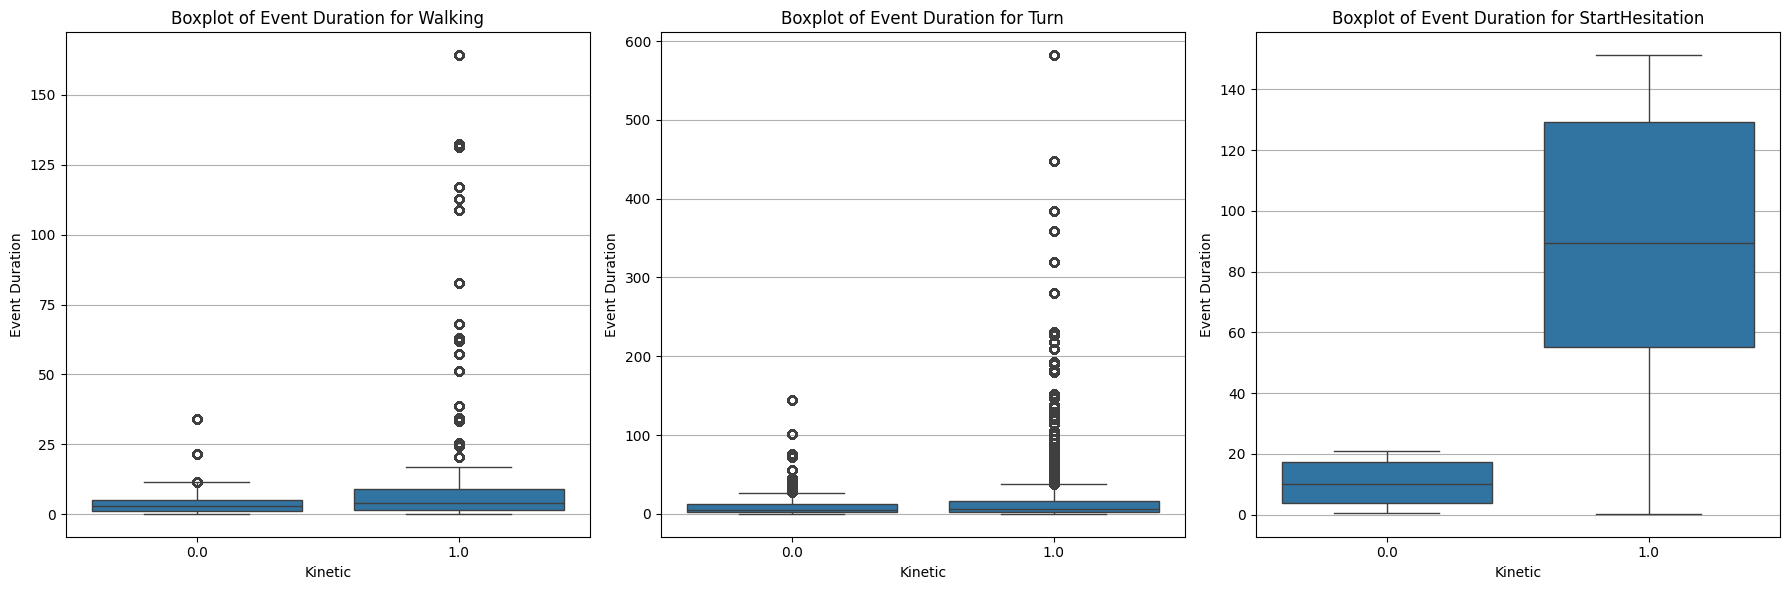

In [106]:
event_types = ['Walking', 'Turn', 'StartHesitation']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, event_type in zip(axes, event_types):
    sns.boxplot(data=train_event_merged_df[train_event_merged_df['Type'] == event_type],
                 x='Kinetic', 
                 y='Event_Duration', 
                 ax=ax,
                 dodge=True)  
    
    ax.set_title(f'Boxplot of Event Duration for {event_type}')
    ax.set_xlabel('Kinetic')
    ax.set_ylabel('Event Duration')
    ax.grid(axis='y')

plt.tight_layout()
plt.show()

In [68]:
events_df[events_df.Id=='f9fc61ce85']

,Id,Init,Completion,Type,Kinetic
3538,f9fc61ce85,20.060,20.980,Turn,1.0
3539,f9fc61ce85,620.740,623.845,Walking,0.0
3540,f9fc61ce85,774.678,774.833,Walking,1.0
3541,f9fc61ce85,924.119,925.627,Turn,1.0
3542,f9fc61ce85,983.039,984.038,Turn,0.0
3543,f9fc61ce85,1172.647,1173.438,Turn,1.0


In [ ]:
####

In [32]:
X = merged_data[['Medication', 'Kinetic', 'Task', 'Age', 'Sex', 'YearsSinceDx']]
y = merged_data[['UPDRSIII_On', 'UPDRSIII_Off', 'NFOGQ']]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [33]:
# Encoding categorical features using OneHotEncoder

categorical_features = ['Task']
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

X_train_encoded = encoder.fit_transform(X_train[categorical_features])
X_test_encoded = encoder.transform(X_test[categorical_features])

In [34]:
# Standardizing numerical features
numeric_features = ['Medication', 'Kinetic', 'Age', 'Sex', 'YearsSinceDx']
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train[numeric_features]), columns=numeric_features)
X_test_scaled = pd.DataFrame(scaler.transform(X_test[numeric_features]), columns=numeric_features)

In [35]:
# Concatenating the transformed features

X_train_encoded_df = pd.DataFrame(X_train_encoded, columns=encoder.get_feature_names_out(categorical_features))
X_test_encoded_df = pd.DataFrame(X_test_encoded, columns=encoder.get_feature_names_out(categorical_features))
X_train_processed = pd.concat([X_train_encoded_df, X_train_scaled], axis=1)
X_test_processed = pd.concat([X_test_encoded_df, X_test_scaled], axis=1)

In [36]:
# Handling missing values

imputer = SimpleImputer(strategy='mean')
X_train_processed = pd.DataFrame(imputer.fit_transform(X_train_processed), columns=X_train_processed.columns)
X_test_processed = pd.DataFrame(imputer.transform(X_test_processed), columns=X_test_processed.columns)

In [37]:
# Creating and training the model for UPDRSIII_On

logistic_regression_on = LogisticRegression(max_iter=5000)
logistic_regression_on.fit(X_train_processed, y_train['UPDRSIII_On'])

# Creating and training the model for UPDRSIII_Off

logistic_regression_off = LogisticRegression(max_iter=5000)
logistic_regression_off.fit(X_train_processed, y_train['UPDRSIII_Off'])

# Creating and training the model for NFOGQ

logistic_regression_nfogq = LogisticRegression(max_iter=5000)
logistic_regression_nfogq.fit(X_train_processed, y_train['NFOGQ'])

y_train_pred_on = logistic_regression_on.predict(X_train_processed)
y_test_pred_on = logistic_regression_on.predict(X_test_processed)

y_train_pred_off = logistic_regression_off.predict(X_train_processed)
y_test_pred_off = logistic_regression_off.predict(X_test_processed)

y_train_pred_nfogq = logistic_regression_nfogq.predict(X_train_processed)
y_test_pred_nfogq = logistic_regression_nfogq.predict(X_test_processed)

In [38]:
from joblib import dump

# Creating and training the combined model

combined_model = {
    'UPDRSIII_On': logistic_regression_on,
    'UPDRSIII_Off': logistic_regression_off,
    'NFOGQ': logistic_regression_nfogq
}

# Saving the combined model

dump(combined_model, 'combined_model.joblib')

['combined_model.joblib']

In [39]:
metrics_results = []

# Metrics for the model UPDRSIII_On
class_name = 'UPDRSIII_On'
train_accuracy = accuracy_score(y_train[class_name], y_train_pred_on)
test_accuracy = accuracy_score(y_test[class_name], y_test_pred_on)
f1 = f1_score(y_test[class_name], y_test_pred_on, average='weighted')

metrics_results.append({
    'Class': class_name,
    'Train Accuracy': train_accuracy,
    'Test Accuracy': test_accuracy,
    'F1 Score': f1
})

# Metrics for the model UPDRSIII_Off
class_name = 'UPDRSIII_Off'
train_accuracy = accuracy_score(y_train[class_name], y_train_pred_off)
test_accuracy = accuracy_score(y_test[class_name], y_test_pred_off)
f1 = f1_score(y_test[class_name], y_test_pred_off, average='weighted')

metrics_results.append({
    'Class': class_name,
    'Train Accuracy': train_accuracy,
    'Test Accuracy': test_accuracy,
    'F1 Score': f1
})

# Metrics for the model NFOGQ
class_name = 'NFOGQ'
train_accuracy = accuracy_score(y_train[class_name], y_train_pred_nfogq)
test_accuracy = accuracy_score(y_test[class_name], y_test_pred_nfogq)
f1 = f1_score(y_test[class_name], y_test_pred_nfogq, average='weighted')

metrics_results.append({
    'Class': class_name,
    'Train Accuracy': train_accuracy,
    'Test Accuracy': test_accuracy,
    'F1 Score': f1
})

# Output of the results
for metrics in metrics_results:
    print(f"Metrics for class '{metrics['Class']}':")
    print(f"Train Accuracy: {metrics['Train Accuracy']}")
    print(f"Test Accuracy: {metrics['Test Accuracy']}")
    print(f"F1 Score: {metrics['F1 Score']}")
    print()

Metrics for class 'UPDRSIII_On':
Train Accuracy: 0.9460138104205901
Test Accuracy: 0.924812030075188
F1 Score: 0.9235605929573596

Metrics for class 'UPDRSIII_Off':
Train Accuracy: 0.9409918392969241
Test Accuracy: 0.9323308270676691
F1 Score: 0.9128055741447861

Metrics for class 'NFOGQ':
Train Accuracy: 0.9522912743251726
Test Accuracy: 0.9323308270676691
F1 Score: 0.923362623426035



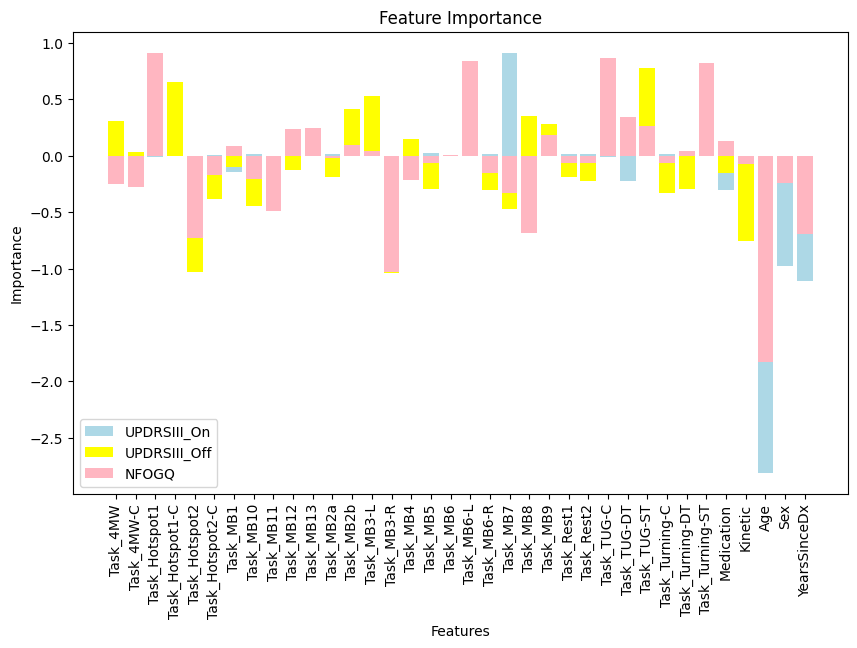

In [40]:
# Creating a list of feature labels for the x-axis

x_labels = X_train_processed.columns

# Creating the plot

plt.figure(figsize=(10, 6))
plt.bar(x_labels, logistic_regression_on.coef_[0], color='lightblue', label='UPDRSIII_On')
plt.bar(x_labels, logistic_regression_off.coef_[0], color='yellow', label='UPDRSIII_Off')
plt.bar(x_labels, logistic_regression_nfogq.coef_[0], color='lightpink', label='NFOGQ')

# Plot settings

plt.title("Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.xticks(rotation=90)
plt.legend()

# Displaying the plot

plt.show()